# Marginal Probability

This notebook explains **marginal probability**, which is the probability of a single event occurring, irrespective of the outcomes of other random variables. We will see how to compute it from a joint probability distribution by "summing out" or "marginalizing" the other variables.


## What is Marginal Probability?

The **marginal probability** is the probability of a single random variable taking on a specific value. For a random variable $X$, the marginal probability that $X=x_i$ is written as $P(X=x_i)$.

When we have a joint distribution of two variables, $X$ and $Y$, we can find the marginal probability of $X$ by summing the joint probabilities over all possible values of $Y$. This process is called **marginalization**.

**Formula for Marginal Probability of X:**
To find the probability of $X=x_i$, we sum the joint probabilities $P(X=x_i, Y=y_j)$ across all possible values of $j$ for $Y$.

$P(X = x_i) = \sum_{j} P(X = x_i, Y = y_j)$

**Formula for Marginal Probability of Y:**
Similarly, to find the probability of $Y=y_j$, we sum the joint probabilities across all possible values of $i$ for $X$.

$P(Y = y_j) = \sum_{i} P(X = x_i, Y = y_j)$


## Example: From Joint to Marginal

Let's use our example of 100 colored shapes.
- **X (Color):** {Red, Green, Blue}
- **Y (Shape):** {Sphere, Cube}

The joint probability table is:


In [8]:
import pandas as pd

# The same joint probability table from the previous notebook
counts = pd.DataFrame(
    [[18, 12, 30],
     [16, 20, 4]],
    index=['Shape=S', 'Shape=C'],
    columns=['Color=R', 'Color=G', 'Color=B']
)
joint_prob = counts / counts.values.sum()

# --- Calculating Marginal Probabilities ---

# To get P(Color), we sum the columns (marginalize out Shape)
marginal_color = joint_prob.sum(axis=0)

# To get P(Shape), we sum the rows (marginalize out Color)
marginal_shape = joint_prob.sum(axis=1)


print("--- Joint Probability Table P(X,Y) ---")
display(joint_prob)

print("\\n--- Marginal Probability of Color P(X) ---")
print("Sum down the columns of the joint table.")
display(marginal_color.to_frame('P(Color)'))

print("\\n--- Marginal Probability of Shape P(Y) ---")
print("Sum across the rows of the joint table.")
display(marginal_shape.to_frame('P(Shape)'))

# Verification
print(f"\\nCheck P(Color=R): {joint_prob.loc['Shape=S', 'Color=R']:.2f} + {joint_prob.loc['Shape=C', 'Color=R']:.2f} = {marginal_color['Color=R']:.2f}")
print(f"Check P(Shape=S): {joint_prob.loc['Shape=S', 'Color=R']:.2f} + {joint_prob.loc['Shape=S', 'Color=G']:.2f} + {joint_prob.loc['Shape=S', 'Color=B']:.2f} = {marginal_shape['Shape=S']:.2f}")


Joint probability table:


,X=R,X=G,X=B
Y=S,0.18,0.12,0.30
Y=C,0.16,0.20,0.04


Marginal probability of X (sum down columns):


,P(X)
X=R,0.34
X=G,0.32
X=B,0.34


Marginal probability of Y (sum across rows):


,P(Y)
Y=S,0.6
Y=C,0.4


## Summary

- **Marginal Probability** is the probability of a single event, found by summing over all other events in a joint distribution.
- This process is called **marginalization**.
- In a table, you find marginal probabilities by summing across rows or down columns.
- For example, $P(A) = P(A \text{ and } B_1) + P(A \text{ and } B_2) + \dots$


## Visualizing Marginal Probability with a Venn Diagram

A Venn diagram helps visualize marginal probability. The marginal probability of an event A, $P(A)$, represents the entire area of the circle for A.

This area is composed of two disjoint parts:
1.  The part of A that does not overlap with B ($A \setminus B$).
2.  The part of A that overlaps with B ($A \cap B$).

Therefore, the marginal probability $P(A)$ is the sum of the probabilities of these two parts:

$P(A) = P(A \setminus B) + P(A \cap B)$


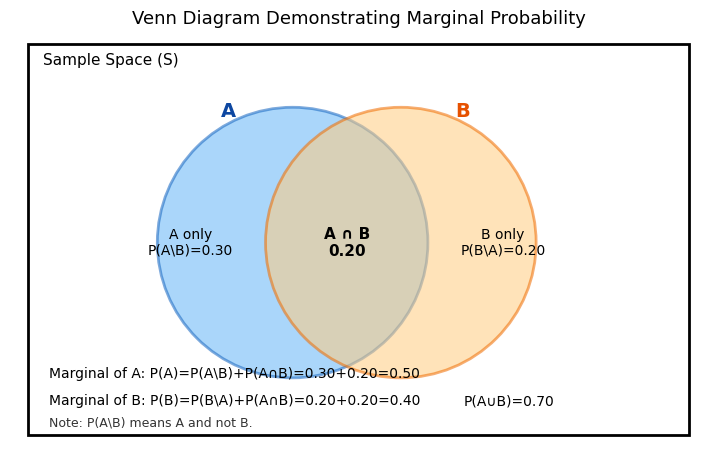

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# Probabilities of the disjoint regions
p_a_only = 0.30
p_b_only = 0.20
p_intersection = 0.20

# Calculate marginal probabilities from the regions
p_a = p_a_only + p_intersection
p_b = p_b_only + p_intersection

fig, ax = plt.subplots(figsize=(8, 5))

# Draw sample space
ax.add_patch(Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='black'))
ax.text(0.2, 5.7, 'S', fontsize=12, fontweight='bold')

# Draw circles for events A and B
circle_a = Circle((4.0, 3.0), 2.0, facecolor='#64b5f6', alpha=0.6, label='A')
circle_b = Circle((6.0, 3.0), 2.0, facecolor='#ffcc80', alpha=0.6, label='B')
ax.add_patch(circle_a)
ax.add_patch(circle_b)

# Labels for the regions
ax.text(2.8, 3.0, f'$P(A \\setminus B)$\n{p_a_only:.2f}', ha='center', va='center', fontsize=11)
ax.text(5.0, 3.0, f'$P(A \\cap B)$\n{p_intersection:.2f}', ha='center', va='center', fontsize=11, weight='bold')
ax.text(7.2, 3.0, f'$P(B \\setminus A)$\n{p_b_only:.2f}', ha='center', va='center', fontsize=11)

# Annotate the marginal probabilities
ax.text(4.0, 5.2, f'Marginal P(A) = {p_a:.2f}', ha='center', fontsize=12, weight='bold', color='#0d47a1')
ax.text(6.0, 0.8, f'Marginal P(B) = {p_b:.2f}', ha='center', fontsize=12, weight='bold', color='#e65100')

# Add formula annotations
ax.text(2.5, 0.3, f'$P(A) = P(A \\setminus B) + P(A \\cap B) = {p_a_only:.2f} + {p_intersection:.2f} = {p_a:.2f}$', fontsize=10)
ax.text(2.5, 0.8, 'The entire blue circle represents P(A)', fontsize=10, style='italic')


ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Marginal Probability as the Sum of Disjoint Regions', fontsize=14)
plt.show()
